In [1]:
import numpy as np
import pandas as pd 
import torch 
import matplotlib.pyplot as plt 

In [2]:
import os 
os.chdir('/kaggle/input/data-diff') #Define Data Directory

In [3]:
import torch
from torch.utils.data import Dataset
import torch.nn.functional as F
import numpy as np

class SuperresDataset(Dataset):
    def __init__(self, hr_images, lr_images, max_images=None):
        """
        Initialize the SuperresDataset.
        Parameters:
        - hr_images (numpy array): High-resolution images of shape (N, 1, 128, 128).
        - lr_images (numpy array): Low-resolution images of shape (N, 1, 64, 64).
        - max_images (int, optional): Maximum number of images to use.
        """
        self.hr_images = torch.from_numpy(self.normalize(hr_images))
        self.lr_images = torch.from_numpy(self.normalize(lr_images))
        
        if max_images is not None:
            self.hr_images = self.hr_images[:max_images]
            self.lr_images = self.lr_images[:max_images]
        
    def __len__(self):
        return len(self.hr_images)

    def __getitem__(self, idx):
        """
        Get the interpolated low-resolution image and high-resolution image at the specified index.
        Parameters:
        - idx (int): Index of the image to retrieve.
        Returns:
        - tuple of torch.Tensor: Interpolated low-resolution image and high-resolution image.
        """
        hr = self.hr_images[idx]
        lr = self.lr_images[idx]
        
        # Interpolate LR image to the size of HR image
        lr_interpolated = F.interpolate(lr.unsqueeze(0), size=(128, 128), mode='bilinear', align_corners=False)
        
        return lr_interpolated.squeeze(0), hr

    @staticmethod
    def normalize(x):
        """
        Normalize the images to [0, 1] range.
        """
        return (x - np.min(x)) / (np.max(x) - np.min(x))

In [4]:
hr_images = np.load('HR_new.npy')
lr_images = np.load('LR_new.npy')

In [5]:
import numpy as np
import torch
from torch.utils.data import DataLoader

total_samples = len(hr_images)
train_size = int(0.90 * total_samples)
test_size = total_samples - train_size
indices = np.arange(total_samples)
np.random.shuffle(indices)
train_indices, test_indices = indices[:train_size], indices[train_size:]

train_dataset = SuperresDataset([hr_images[i] for i in train_indices], [lr_images[i] for i in train_indices])
test_dataset = SuperresDataset([hr_images[i] for i in test_indices], [lr_images[i] for i in test_indices])

batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [6]:
dataiter = iter(train_loader)
batch = next(dataiter)

hr_images = batch[1]
min_val = hr_images.min().item()
max_val = hr_images.max().item()

print(f"Min value: {min_val}, Max value: {max_val}")

Min value: 0.042277559638023376, Max value: 0.9411404728889465


# Forward Process

In [7]:
import torch
import numpy as np
from tqdm import tqdm

class Diffusion:
    def __init__(self, noise_steps=1000, beta_start=1e-4, beta_end=0.02, img_size=64, device="cuda"):
        self.noise_steps = noise_steps
        self.beta_start = beta_start
        self.beta_end = beta_end
        self.img_size = img_size
        self.device = device

        self.beta = self.prepare_noise_schedule().to(device)
        self.alpha = 1. - self.beta
        self.alpha_hat = torch.cumprod(self.alpha, dim=0)

    def prepare_noise_schedule(self):
        timesteps = torch.linspace(0, 1, self.noise_steps)
        s = 0.008
        beta_schedule = (1 - torch.cos((timesteps + s) / (1 + s) * np.pi)) / 2
        beta_schedule = beta_schedule * (self.beta_end - self.beta_start) + self.beta_start
        return beta_schedule

    def noise_images(self, x, t):
        sqrt_alpha_hat = torch.sqrt(self.alpha_hat[t])[:, None, None, None]
        sqrt_one_minus_alpha_hat = torch.sqrt(1 - self.alpha_hat[t])[:, None, None, None]
        Ɛ = torch.randn_like(x)
        return sqrt_alpha_hat * x + sqrt_one_minus_alpha_hat * Ɛ, Ɛ

    def sample_timesteps(self, n):
        return torch.randint(low=1, high=self.noise_steps, size=(n,))

    def sample(self, model, n, lat):
        print(f"Sampling {n} new images....")
        model.eval()
        with torch.no_grad():
            x = torch.randn((n, 1, self.img_size, self.img_size)).to(self.device)
            for i in tqdm(reversed(range(1, self.noise_steps)), position=0):
                t = (torch.ones(n) * i).long().to(self.device)
                predicted_noise = model(x, t, lat)
                alpha = self.alpha[t][:, None, None, None]
                alpha_hat = self.alpha_hat[t][:, None, None, None]
                beta = self.beta[t][:, None, None, None]
                if i > 1:
                    noise = torch.randn_like(x)
                else:
                    noise = torch.zeros_like(x)
                x = 1 / torch.sqrt(alpha) * (x - ((1 - alpha) / (torch.sqrt(1 - alpha_hat))) * predicted_noise) + torch.sqrt(beta) * noise
        model.train()
        x = (x.clamp(-1, 1) + 1) / 2
        x = (x - torch.amin(x))/(torch.amax(x) - torch.amin(x))
        return x


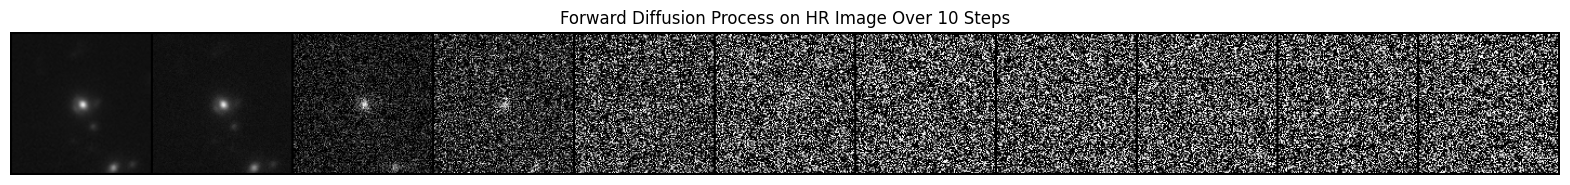

In [8]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

diffusion = Diffusion(noise_steps=1000, img_size=128, device="cuda")

dataiter = iter(train_loader)
batch = next(dataiter)

hr_images = batch[1].to(diffusion.device)

hr_image = hr_images[0].unsqueeze(0) 
noisy_images = [hr_image.cpu()]  

for i in range(0, diffusion.noise_steps, diffusion.noise_steps // 10):
    t = torch.tensor([i]).to(diffusion.device)
    noisy_image, _ = diffusion.noise_images(hr_image, t)
    noisy_images.append(noisy_image.cpu())

noisy_images = torch.cat(noisy_images, dim=0)

grid = make_grid(noisy_images, nrow=11, normalize=True, value_range=(0, 1))

plt.figure(figsize=(20, 20))
plt.imshow(grid.permute(1, 2, 0))
plt.axis('off')
plt.title("Forward Diffusion Process on HR Image Over 10 Steps")
plt.show()

# UNet Model 

In [9]:
!pip install einops

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 kB 623.4 kB/s eta 0:00:000:00:01


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from torch.autograd import Variable
import math
from einops import rearrange
from inspect import isfunction

def default(val, d):
    if val is not None:
        return val
    return d() if isfunction(d) else d

def cycle(dl):
    while True:
        for data in dl:
            yield data

def num_to_groups(num, divisor):
    groups = num // divisor
    remainder = num % divisor
    arr = [divisor] * groups
    if remainder > 0:
        arr.append(remainder)
    return arr

class EMA():
    def __init__(self, beta):
        super().__init__()
        self.beta = beta

    def update_model_average(self, ma_model, current_model):
        for current_params, ma_params in zip(current_model.parameters(), ma_model.parameters()):
            old_weight, up_weight = ma_params.data, current_params.data
            ma_params.data = self.update_average(old_weight, up_weight)

    def update_average(self, old, new):
        if old is None:
            return new
        return old * self.beta + (1 - self.beta) * new

class Residual(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn

    def forward(self, x, *args, **kwargs):
        return self.fn(x, *args, **kwargs) + x

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        device = x.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = x[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

class Upsample(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.conv = nn.ConvTranspose2d(dim, dim, 4, 2, 1)

    def forward(self, x):
        return self.conv(x)

class Downsample(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.conv = nn.Conv2d(dim, dim, 3, 2, 1)

    def forward(self, x):
        return self.conv(x)

class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.fn = fn
        self.norm = nn.InstanceNorm2d(dim, affine = True)

    def forward(self, x):
        x = self.norm(x)
        return self.fn(x)

class Rezero(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn
        self.g = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        return self.fn(x) * self.g

class Block(nn.Module):
    def __init__(self, dim, dim_out, groups = 8):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(dim, dim_out, 3, padding=1),
            nn.GroupNorm(groups, dim_out),
            Mish()
        )
    def forward(self, x):
        return self.block(x)

class ResnetBlock(nn.Module):
    def __init__(self, dim, dim_out, *, time_emb_dim, cond_dim, groups=8):
        super().__init__()
        self.mlp = nn.Sequential(
            Mish(),
            nn.Linear(time_emb_dim, dim_out)
        )

        self.block1 = Block(dim + cond_dim, dim_out)
        self.block2 = Block(dim_out, dim_out)
        self.res_conv = nn.Conv2d(dim + cond_dim, dim_out, 1) if dim + cond_dim != dim_out else nn.Identity()

    def forward(self, x, time_emb, cond):
        cond = nn.functional.interpolate(cond, size=x.shape[-2:], mode='bilinear', align_corners=False)

        x_cond = torch.cat([x, cond], dim=1)

        h = self.block1(x_cond)
        h += self.mlp(time_emb)[:, :, None, None]
        h = self.block2(h)

        return h + self.res_conv(x_cond)

class LinearAttention(nn.Module):
    def __init__(self, dim, heads = 4, dim_head = 32):
        super().__init__()
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias = False)
        self.to_out = nn.Conv2d(hidden_dim, dim, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x)
        q, k, v = rearrange(qkv, 'b (qkv heads c) h w -> qkv b heads c (h w)', heads = self.heads, qkv=3)
        k = k.softmax(dim=-1)
        context = torch.einsum('bhdn,bhen->bhde', k, v)
        out = torch.einsum('bhde,bhdn->bhen', context, q)
        out = rearrange(out, 'b heads c (h w) -> b (heads c) h w', heads=self.heads, h=h, w=w)
        return self.to_out(out)

class Unet(nn.Module):
    def __init__(self, dim=128, out_dim=None, dim_mults=(1, 2, 4, 8), groups=8, channels=1, cond_channels=1):
        super().__init__()
        self.channels = channels

        dims = [channels, *map(lambda m: dim * m, dim_mults)]
        in_out = list(zip(dims[:-1], dims[1:]))

        self.time_pos_emb = SinusoidalPosEmb(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4),
            Mish(),
            nn.Linear(dim * 4, dim)
        )

        self.downs = nn.ModuleList([])
        self.ups = nn.ModuleList([])
        num_resolutions = len(in_out)

        for ind, (dim_in, dim_out) in enumerate(in_out):
            is_last = ind >= (num_resolutions - 1)

            self.downs.append(nn.ModuleList([
                ResnetBlock(dim_in, dim_out, time_emb_dim=dim, cond_dim=cond_channels),
                ResnetBlock(dim_out, dim_out, time_emb_dim=dim, cond_dim=cond_channels),
                Residual(Rezero(LinearAttention(dim_out))),
                Downsample(dim_out) if not is_last else nn.Identity()
            ]))

        mid_dim = dims[-1]
        self.mid_block1 = ResnetBlock(mid_dim, mid_dim, time_emb_dim=dim, cond_dim=cond_channels)
        self.mid_attn = Residual(Rezero(LinearAttention(mid_dim)))
        self.mid_block2 = ResnetBlock(mid_dim, mid_dim, time_emb_dim=dim, cond_dim=cond_channels)

        for ind, (dim_in, dim_out) in enumerate(reversed(in_out[1:])):
            is_last = ind >= (num_resolutions - 1)

            self.ups.append(nn.ModuleList([
                ResnetBlock(dim_out * 2, dim_in, time_emb_dim=dim, cond_dim=cond_channels),
                ResnetBlock(dim_in, dim_in, time_emb_dim=dim, cond_dim=cond_channels),
                Residual(Rezero(LinearAttention(dim_in))),
                Upsample(dim_in) if not is_last else nn.Identity()
            ]))

        out_dim = default(out_dim, channels)
        self.final_conv = nn.Sequential(
            Block(dim, dim),
            nn.Conv2d(dim, out_dim, 1)
        )

    def forward(self, x, time, cond):
        t = self.time_pos_emb(time)
        t = self.mlp(t)

        h = []

        # Downsampling path
        for resnet, resnet2, attn, downsample in self.downs:
            x = resnet(x, t, cond)
            x = resnet2(x, t, cond)
            x = attn(x)
            h.append(x)
            x = downsample(x)

        # Middle blocks
        x = self.mid_block1(x, t, cond)
        x = self.mid_attn(x)
        x = self.mid_block2(x, t, cond)

        # Upsampling path
        for resnet, resnet2, attn, upsample in self.ups:
            x = torch.cat((x, h.pop()), dim=1)
            x = resnet(x, t, cond)
            x = resnet2(x, t, cond)
            x = attn(x)
            x = upsample(x)

        return self.final_conv(x)

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
import torch
from tqdm import tqdm
import os

def train(model, diffusion, train_loader, optimizer, epochs, device, save_dir='/kaggle/working/'):
    best_loss = float('inf')
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        print(f"Epoch {epoch+1}/{epochs}")
        progress_bar = tqdm(train_loader, desc=f"Training", leave=True)
        
        for batch in progress_bar:
            optimizer.zero_grad()
            
            lr, hr = batch
            images = hr.to(device)
            conditions = lr.to(device)
            
            t = diffusion.sample_timesteps(images.shape[0]).to(device)
            x_t, noise = diffusion.noise_images(images, t)
            
            predicted_noise = model(x_t, t, conditions)
            
            loss = F.l1_loss(noise, predicted_noise)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
            # Update progress bar
            progress_bar.set_postfix({"Loss": f"{loss.item():.4f}"})
        
        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{epochs}, Average Loss: {avg_loss:.4f}")
        
        # Save the best model
        if avg_loss < best_loss:
            best_loss = avg_loss
            best_model_path = os.path.join(save_dir, 'best_model.pth')
            torch.save(model.state_dict(), best_model_path)
            print(f"New best model saved with loss: {best_loss:.4f}")
        
        print()  
    
    print("Training completed!")
    print(f"Best model saved with loss: {best_loss:.4f}")

In [13]:
model = Unet().to(device)
diffusion = Diffusion(noise_steps=1000, img_size=128, device=device)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)
train(model, diffusion, train_loader, optimizer, epochs=100, device=device)

Epoch 1/100


Training: 100%|██████████| 638/638 [04:40<00:00,  2.28it/s, Loss=0.0688]


Epoch 1/100, Average Loss: 0.1483
New best model saved with loss: 0.1483

Epoch 2/100


Training: 100%|██████████| 638/638 [04:47<00:00,  2.22it/s, Loss=0.0505]


Epoch 2/100, Average Loss: 0.0678
New best model saved with loss: 0.0678

Epoch 3/100


...

Training: 100%|██████████| 638/638 [04:47<00:00,  2.22it/s, Loss=0.0075]


Epoch 56/100, Average Loss: 0.0168

Epoch 57/100


Training: 100%|██████████| 638/638 [04:47<00:00,  2.22it/s, Loss=0.0138]


Epoch 57/100, Average Loss: 0.0166

Epoch 58/100


Training:  97%|█████████▋| 620/638 [04:40<00:08,  2.21it/s, Loss=0.0065]

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
train(model, diffusion, train_loader, optimizer, epochs=100, device=device)

Epoch 1/100


Training: 100%|██████████| 638/638 [04:32<00:00,  2.34it/s, Loss=0.0051]


Epoch 1/100, Average Loss: 0.0136
New best model saved with loss: 0.0136

Epoch 2/100


Training: 100%|██████████| 638/638 [04:40<00:00,  2.28it/s, Loss=0.0284]


Epoch 2/100, Average Loss: 0.0135
New best model saved with loss: 0.0135

Epoch 3/100


...

Training: 100%|██████████| 638/638 [04:48<00:00,  2.21it/s, Loss=0.0052]


Epoch 9/100, Average Loss: 0.0123
New best model saved with loss: 0.0123

Epoch 10/100


Training: 100%|██████████| 638/638 [04:48<00:00,  2.21it/s, Loss=0.0115]


Epoch 10/100, Average Loss: 0.0131

Epoch 11/100


Training:  71%|███████▏  | 456/638 [03:26<01:21,  2.22it/s, Loss=0.0104]

In [14]:
load_path = "/kaggle/working/best_model.pth"
model.load_state_dict(torch.load(load_path))

<All keys matched successfully>

In [ ]:
save_path = "/kaggle/working/diffusion.pth"
torch.save(model.state_dict(), save_path)
print("Saved Successfully")

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from tqdm import tqdm

def sample_and_plot(model, diffusion, batch, device, num_samples=4):
    model.eval()
    with torch.no_grad():
        lr_batch, hr_batch = batch
        lr_batch = lr_batch.to(device)
        
        sr_batch = diffusion.sample(model, n=lr_batch.shape[0], lat=lr_batch)
        sr_batch = sr_batch.cpu().numpy()
        

    # Plot results
    num_samples = min(num_samples, lr_batch.shape[0])
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 5*num_samples))
    
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for i in range(num_samples):
        # LR image
        axes[i, 0].imshow(lr_batch[i, 0].cpu().numpy(), cmap='gray')
        axes[i, 0].set_title('LR Input')
        axes[i, 0].axis('off')

        # SR prediction
        axes[i, 1].imshow(sr_batch[i, 0], cmap='gray')
        axes[i, 1].set_title('SR Prediction')
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

dataiter = iter(test_loader)
batch = next(dataiter)

sample_and_plot(model, diffusion, batch, device, num_samples=4)

Processing test data:   0%|          | 0/71 [00:00<?, ?it/s]

Sampling 4 new images....


999it [02:42,  6.14it/s]
Processing test data:   1%|▏         | 1/71 [02:42<3:10:08, 162.98s/it]

Sampling 4 new images....


999it [02:41,  6.17it/s]
Processing test data:   3%|▎         | 2/71 [05:24<3:06:43, 162.37s/it]

...

Sampling 4 new images....


999it [02:41,  6.18it/s]
Processing test data:  99%|█████████▊| 70/71 [3:08:58<02:41, 161.84s/it]

Sampling 4 new images....


999it [02:41,  6.18it/s]
Processing test data: 100%|██████████| 71/71 [3:11:40<00:00, 161.98s/it]


Metrics:
Average MSE super resolution samples: 0.0010994
Average l1 super resolution samples: 0.0212453
Average SSIM super resolution samples: 0.48957
Average PSNR super resolution samples: 27.78911


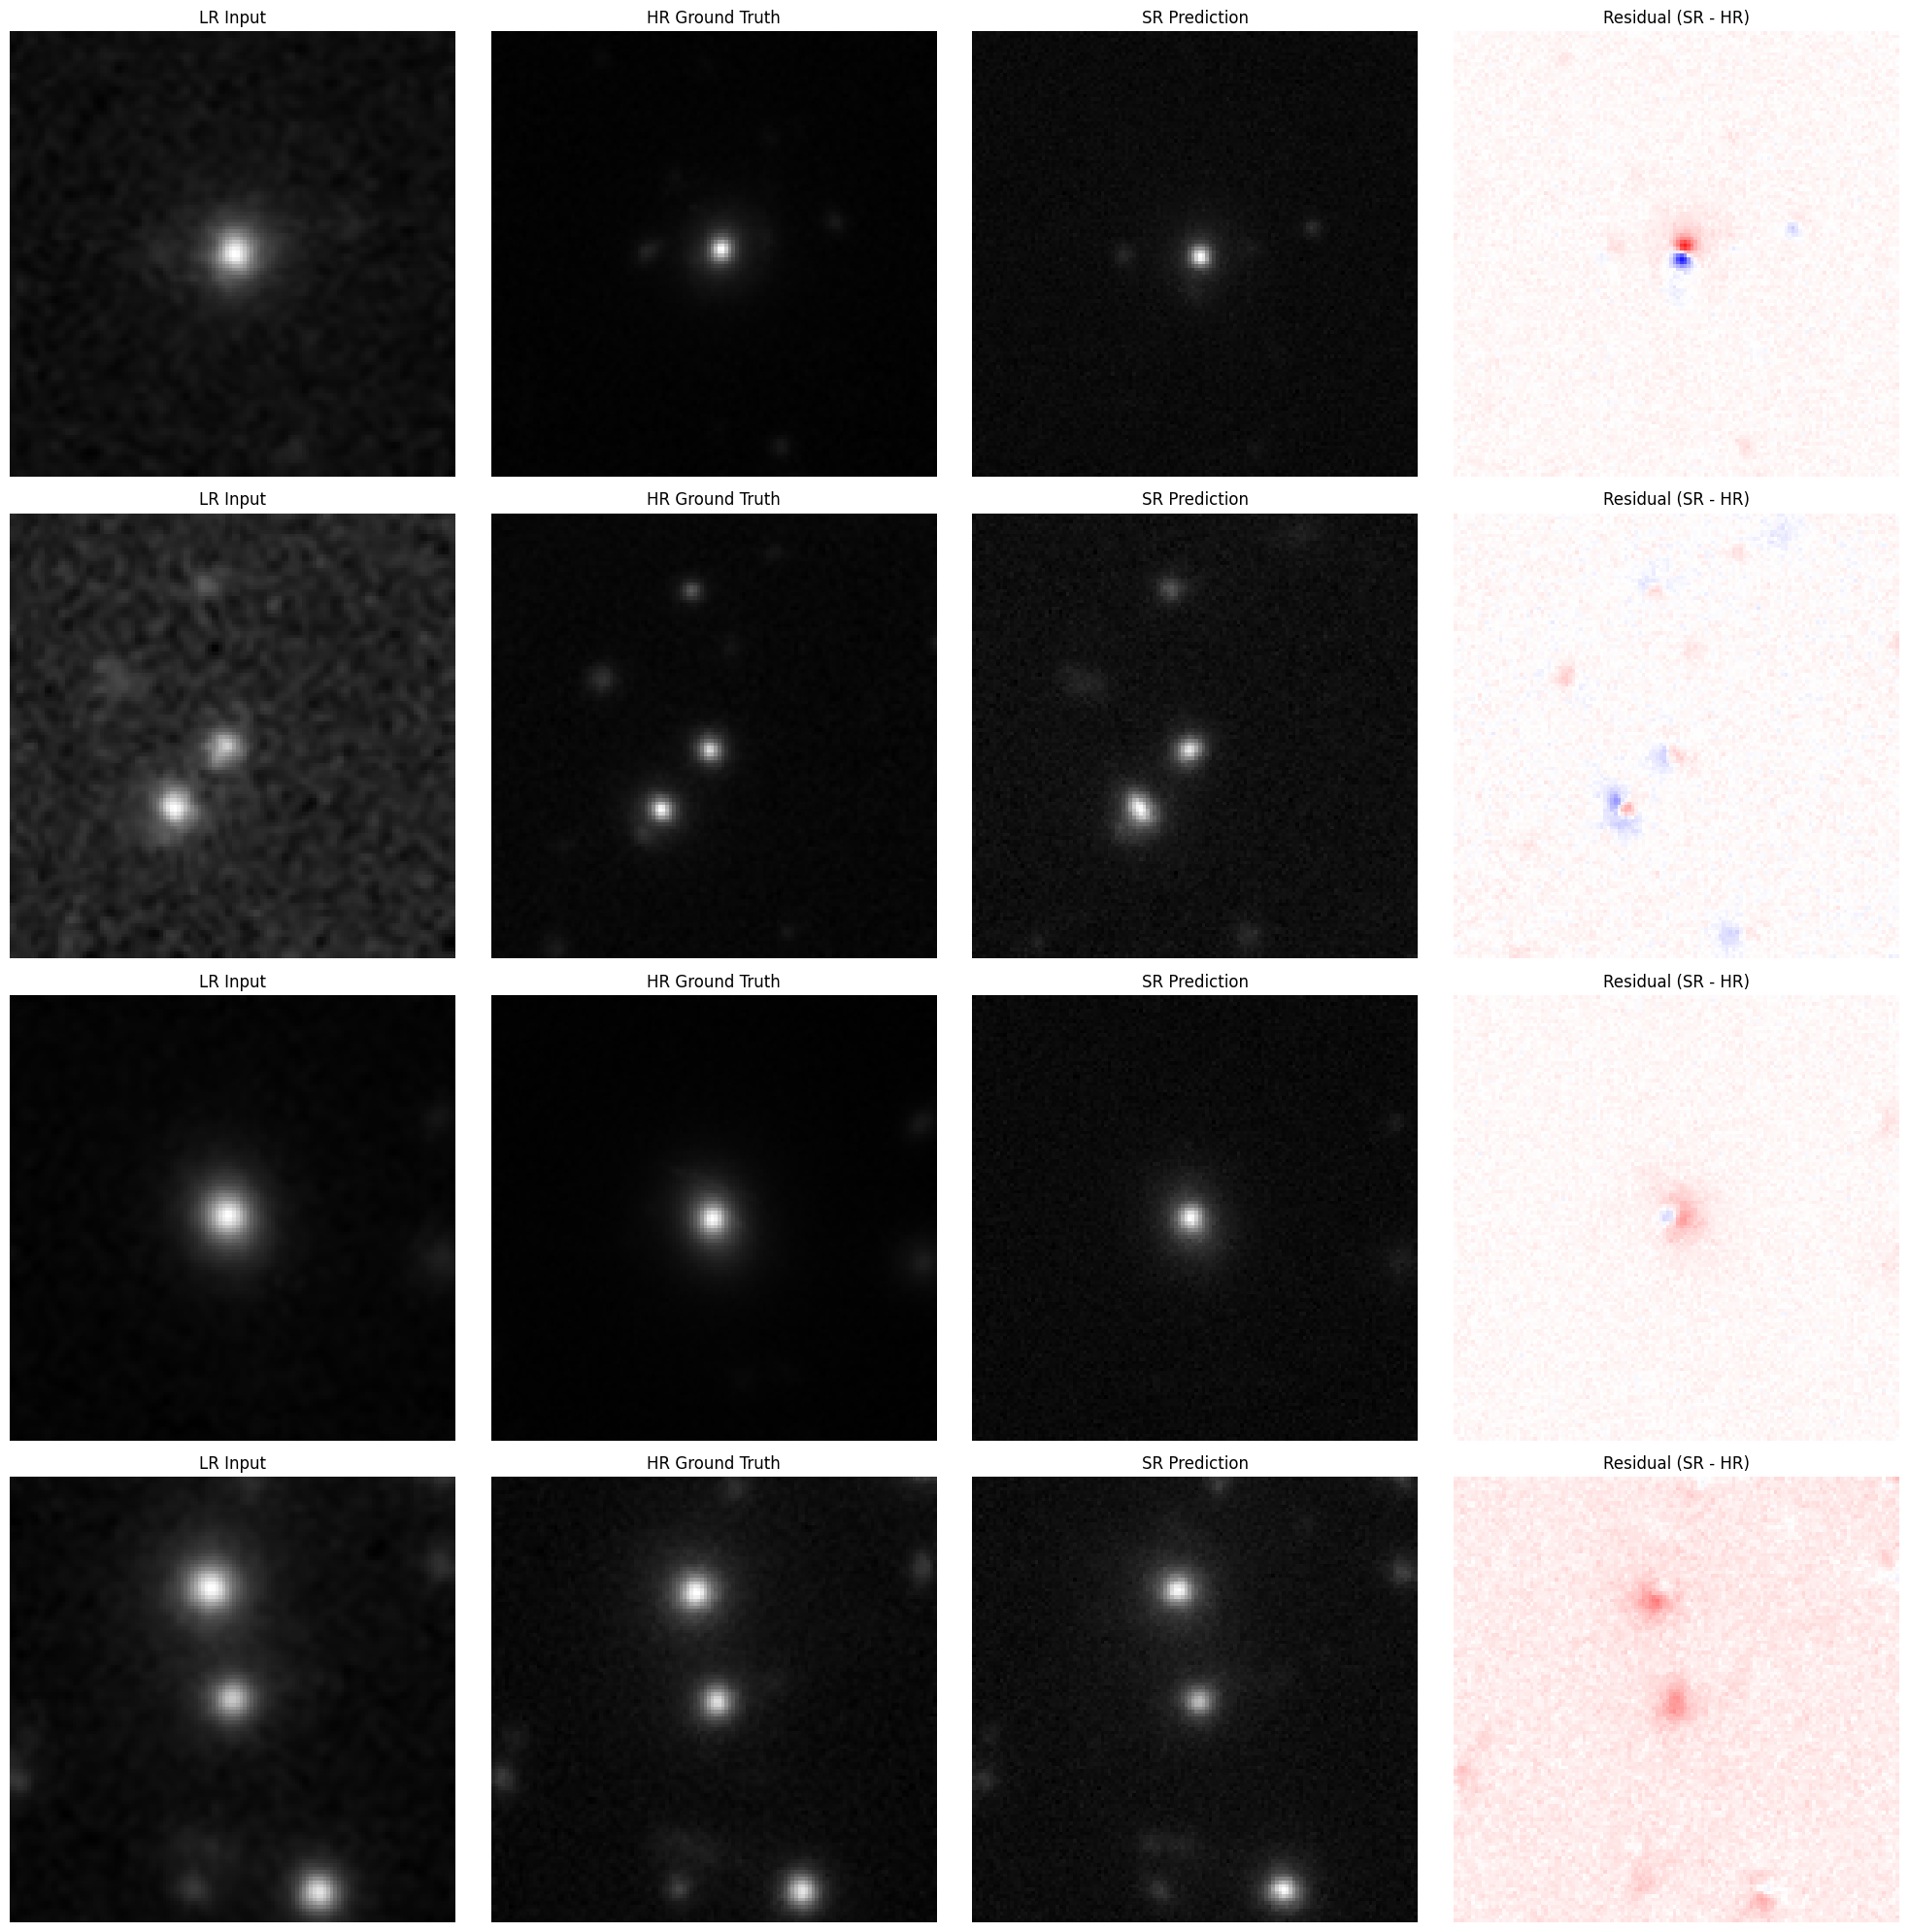

In [20]:
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
%matplotlib inline
import torch
import torch.nn as nn
import numpy as np
import cv2
from tqdm import tqdm


def norma(x):
    return (x - x.min()) / (x.max() - x.min())

# Inference
def inference(model, diffusion, test_loader, device):
    model.eval()
    all_sr = []
    all_hr = []
    all_lr = []
    all_maps = []
    
    with torch.no_grad():
        for lr, hr in tqdm(test_loader, desc="Processing test data"):
            lr = lr.to(device)
            hr = hr.to(device)
            
            sr = diffusion.sample(model, n=lr.shape[0], lat=lr)
            
            all_sr.append(sr.cpu())
            all_hr.append(hr.cpu())
            all_lr.append(lr.cpu())
            all_maps.append((hr - sr).cpu())
    
    return torch.cat(all_lr), torch.cat(all_hr), torch.cat(all_sr), torch.cat(all_maps)

# Run inference
x_test, x, x_out, maps = inference(model, diffusion, test_loader, device)

# Calculate metrics
print("Metrics:")
criteria = nn.MSELoss()
criteria2 = nn.L1Loss()
losses = []
losses2 = []
Ssim = []
Psnr = []

for i in range(x_test.shape[0]):
    losses.append(criteria(x_out[i], x[i]).item())
    losses2.append(criteria2(x_out[i], x[i]).item())

    sr_np = norma(x_out[i, 0].numpy())
    hr_np = norma(x[i, 0].numpy())
    
    Ssim.append(ssim(hr_np, sr_np, data_range=1.0))
    Psnr.append(psnr(hr_np, sr_np, data_range=1.0))

print("Average MSE super resolution samples: " + str('%.7f'%np.average(losses)))
print("Average l1 super resolution samples: " + str('%.7f'%np.average(losses2)))
print("Average SSIM super resolution samples: " + str('%.5f'%np.average(Ssim)))
print("Average PSNR super resolution samples: " + str('%.5f'%np.average(Psnr)))

# Plotting function
def plot_samples(x_test, x, x_out, maps, num_samples=8):
    fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5*num_samples))
    
    for i in range(num_samples):
        # LR image
        axes[i, 0].imshow(x_test[i, 0].numpy(), cmap='gray')
        axes[i, 0].set_title('LR Input')
        axes[i, 0].axis('off')

        # HR image
        axes[i, 1].imshow(x[i, 0].numpy(), cmap='gray')
        axes[i, 1].set_title('HR Ground Truth')
        axes[i, 1].axis('off')

        # SR prediction
        axes[i, 2].imshow(x_out[i, 0].numpy(), cmap='gray')
        axes[i, 2].set_title('SR Prediction')
        axes[i, 2].axis('off')

        # Residual map
        axes[i, 3].imshow(maps[i, 0].numpy(), cmap='bwr', vmin=-0.5, vmax=0.5)
        axes[i, 3].set_title('Residual (SR - HR)')
        axes[i, 3].axis('off')

    plt.tight_layout()
    plt.show()

# Plot samples
plot_samples(x_test, x, x_out, maps, num_samples=4)

In [ ]:
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import torch
import torch.nn as nn
import numpy as np
from tqdm import tqdm

def norma(x):
    return (x - x.min()) / (x.max() - x.min())

# Process multiple batches
def process_batches(model, diffusion, test_loader, device, num_batches=10):
    model.eval()
    all_lr, all_hr, all_sr, all_residual = [], [], [], []
    
    with torch.no_grad():
        for _ in tqdm(range(num_batches), desc="Processing batches"):
            # Get a single batch
            lr, hr = next(iter(test_loader))
            lr = lr.to(device)
            hr = hr.to(device)
           
            sr = diffusion.sample(model, n=lr.shape[0], lat=lr)
        
            residual = hr - sr
            
            all_lr.append(lr.cpu())
            all_hr.append(hr.cpu())
            all_sr.append(sr.cpu())
            all_residual.append(residual.cpu())
    
    return torch.cat(all_lr), torch.cat(all_hr), torch.cat(all_sr), torch.cat(all_residual)

def evaluate_model(model, diffusion, test_loader, device, num_batches=10):
    x_test, x, x_out, maps = process_batches(model, diffusion, test_loader, device, num_batches)

    print("Calculating metrics...")
    criteria = nn.MSELoss()
    criteria2 = nn.L1Loss()
    losses, losses2, Ssim, Psnr = [], [], [], []

    for i in tqdm(range(x_test.shape[0]), desc="Calculating metrics"):
        losses.append(criteria(x_out[i], x[i]).item())
        losses2.append(criteria2(x_out[i], x[i]).item())
     
        sr_np = norma(x_out[i, 0].numpy())
        hr_np = norma(x[i, 0].numpy())
        
        Ssim.append(ssim(hr_np, sr_np, data_range=1.0))
        Psnr.append(psnr(hr_np, sr_np, data_range=1.0))

    print("Metrics:")
    print(f"Average MSE super resolution samples: {np.mean(losses):.7f}")
    print(f"Average L1 super resolution samples: {np.mean(losses2):.7f}")
    print(f"Average SSIM super resolution samples: {np.mean(Ssim):.5f}")
    print(f"Average PSNR super resolution samples: {np.mean(Psnr):.5f}")

    return x_test, x, x_out, maps, losses, losses2, Ssim, Psnr

x_test, x, x_out, maps, losses, losses2, Ssim, Psnr = evaluate_model(model, diffusion, test_loader, device)

In [ ]:
# Plotting function
def plot_samples(x_test, x, x_out, maps, num_samples=4):
    num_samples = min(num_samples, x_test.shape[0])
    fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5*num_samples))
    
    for i in range(num_samples):
        # LR image
        axes[i, 0].imshow(x_test[i, 0].numpy(), cmap='viridis')
        axes[i, 0].set_title('LR Input')
        axes[i, 0].axis('off')

        # HR image
        axes[i, 1].imshow(x[i, 0].numpy(), cmap='viridis')
        axes[i, 1].set_title('HR Ground Truth')
        axes[i, 1].axis('off')

        # SR prediction
        axes[i, 2].imshow(x_out[i, 0].numpy(), cmap='viridis')
        axes[i, 2].set_title('SR Prediction')
        axes[i, 2].axis('off')

        # Residual map
        axes[i, 3].imshow(maps[i, 0].numpy(), cmap='bwr', vmin=-0.5, vmax=0.5)
        axes[i, 3].set_title('Residual (SR - HR)')
        axes[i, 3].axis('off')

    plt.tight_layout()
    plt.show()

# Plot samples
plot_samples(x_test, x, x_out, maps, num_samples=4)